# MITGCM Transect Time Scale Analysis 

**Purpose**: Code for preforming the transect time scale analysis. I will compute the decorrelation time scale along a transect off the  coast of southern california. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize, segment_time_series, bootstrap_decorrelation_scale, windowed_decorrelation_scale, compute_autocorr_optimize
from spectra import spectrum1D_frequency, spectral_slope
from lsf import unweighted_lsf, detrend, compute_amp_phase
from structure_functions import compute_structure_function
from var_analysis import variance_scale_analysis_1D
from ocean_analysis import compute_mld
from plotScaleAnalysis import month_fmt, add_freq_marker

Set data analysis parameters

In [3]:
# Set processing parameters
option_plot          = 0          # Specifies if supplementary plots are plotted
option_var           = 'density'  # Specifies which variable will analyzed. Options include: temp, sal, density, u_along, v_cross

# Set time and space parameters
dt           = 1*(60)*(60)                   # Specifies the time interval for model run. Units: seconds
estimator    = 'biased'                      # Specifies the approach for estimating the autocorrelation function    
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/OSM26/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
if (option_var == 'temp') | (option_var == 'sal') | (option_var == 'density'):
    filename = PATH + "mitgcm_intermediate_data_TSD_hrly_transect_profiles.nc"
elif (option_var == 'u_along') | (option_var == 'v_cross'):
    filename = PATH + "mitgcm_intermediate_data_vel_hrly_transect_profiles.nc"
nc = Dataset(filename, 'r')

# Extract data variables
depth = nc.variables['depth'][:]
lon   = nc.variables['LON'][:]
lat   = nc.variables['LAT'][:]
dist  = nc.variables['DIST'][:]     
time  =  num2date(nc.variables['time'][:], nc.variables['time'].units)

if option_var == 'temp':
    data = nc.variables['CTemp'][:]
elif option_var == 'sal':
    data = nc.variables['ASal'][:]
elif option_var == 'density':
    data = nc.variables['SIG'][:]
elif option_var == 'u_along': 
    data = nc.variables['u_along'][:]
elif option_var == 'v_cross': 
    data = nc.variables['v_cross'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

# Flip the distance axis of the data array to match the orientation of the distance coordinates (increasing from left to right)
lon = lon[::-1]
lat = lat[::-1]
data = data[::-1,:,:]

Load in the ocean bottom land mask

In [5]:
# Set filename and read in netcdf file
filename = PATH + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"
nc = Dataset(filename, 'r')

# Extract data variables
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

Set the locations of each cce mooring

In [6]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53825701527784
lat3 = 34.44825228022894

Slice the data so that the analysis only considers the upper 200 meters and offshore distances up to 123 degrees west

In [7]:
# Find the indices for the upper 200 meters and specified lat and lon bounds
dist_mask = ((lat >= lat_bnds[0]) & (lat <= lat_bnds[1]) & (lon >= lon_bnds[0]) & (lon <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]
idx_depth = np.where(depth >= -215)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
depth = depth[idx_depth]
lat   = lat[idx_dist]
lon   = lon[idx_dist]
dist  = dist[idx_dist]
bottom_depth = bottom_depth[idx_dist]
data  = data[idx_dist, :, :][:, :, idx_depth]

Compute the time-mean transect

In [8]:
data_mean = np.mean(data, axis=1)
data_var = np.var(data, ddof=1, axis=1)

Plot the time-mean data along the transect 

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_30223/2431651401.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


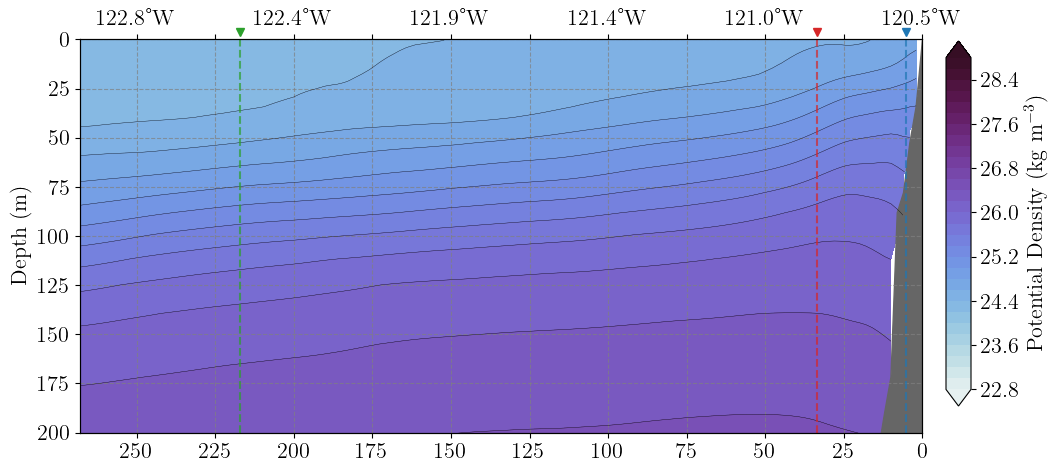

In [9]:
# Set plotting parameters
if option_var == 'temp':
    label = r'Conservative Temperature (deg C)'
    cmap = cmo.thermal
elif option_var == 'sal':
    label = r'Absolute Salinity (g/kg)'
    cmap = cmo.haline
elif option_var == 'density': 
    label = r'Potential Density (kg m$^{-3}$)'
    cmap = cmo.dense
    levels_n = np.arange(22.8,29,0.2)
    levels = np.arange(25, 26 + 0.5, 0.5)
elif option_var == 'u_along': 
    label = r'Along-transect (cross-shore) Velocity (ms$^{-1}$)'
    cmap = cmo.balance
    levels_n = np.arange(-0.15, 0.15+0.005, 0.005)
elif option_var == 'v_cross': 
    label = r'Cross-transect (alongshore) Velocity (ms$^{-1}$)'
    cmap = cmo.balance
    levels_n = np.arange(-0.15, 0.15+0.005, 0.005)

# Create figure
fig, ax = plt.subplots(1,1,figsize=(10,5))

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),data_mean.T, levels=levels_n, cmap=cmap, extend='both')
ax.contour(dist,abs(depth),data_mean.T, levels=levels_n,colors='k',linewidths=0.25)
ax.contour(dist,abs(depth),data_mean.T, levels=[0],colors='k',linewidths=1)

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.7,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(label)

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

Preform scale analysis

In [19]:
# Set parameters
w1, w2        = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec
segment_years = 1 
overlap       = 0.5

# Obtain a example segment 
segments = segment_time_series(time_dt, data[0,:,0], segment_years=segment_years, overlap=overlap)

# Set dimensions     
nseg,ntime  = np.shape(segments)[0], np.shape(segments)[2]
ndist,_,ndepth = np.shape(data)

# Set autocorrelation parameters
lag       = ntime
norm      = 0
estimator = 'biased'

# Convert to seconds since start time
t0 = time_dt[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

# Initialize arrays 
Lt             = np.zeros((ndist,ndepth))
Lt_stdm        = np.zeros((ndist,ndepth))
cn_dist = 0 

# Loop through distance offshore 
for idist in range(0,ndist):
    
    # Set progress bar
    progress = (idist + 1) / (ndist-1)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Set depth counter 
    cn_depth = 0

    # Loop through depth
    for idepth in range(0,ndepth):
        
        # Initialize the ith time series 
        data_ts = data[idist,:,idepth]

        # Try statement to handle masked values associated with land
        try:

            # Remove annual and semi-annual cycle 
            hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
            data_ts_rm = data_ts - hfit

            # Segment the time series 
            segments = segment_time_series(time_dt, data_ts_rm, segment_years=segment_years, overlap=overlap)

            # Initialize arrays
            autocorr_seg   = np.zeros((nseg,ntime))
            time_scale_seg = np.zeros((nseg,ntime))

            # Loop through segments
            for i, (tseg, dseg) in enumerate(segments):

                # Compute the elapsed time from beginning of segmented time series (units: seconds)
                t0 = tseg[0]
                time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
                
                # Detrend data record 
                data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

                # Compute autocorrelation function
                lag = len(time_elapsed_seg)
                autocorr_seg[i,:], _, _, _, time_scale_seg[i,:], _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, lag, estimator, norm)

            # Compute the mean autocorrelation function 
            meanAutocorr = np.nanmean(autocorr_seg, axis=0)

            # Compute the standard deviation and the number of samples 
            stdAutocorr = np.nanstd(autocorr_seg, axis=0, ddof=1)
            nAutocorr   = np.count_nonzero(~np.isnan(autocorr_seg), axis=0)

            # Compute the standard error of the mean (assuming that each data point is an independent observations)
            stdmAutocorr   = stdAutocorr/np.sqrt(nAutocorr)

            # Compute the decorrelation scale 
            Lt[idist,idepth]  = compute_decor_scale_optimize(meanAutocorr,time_scale_seg[0,:],dt,'unbiased',norm)

            # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
            Lt_ustd = compute_decor_scale_optimize(meanAutocorr + stdmAutocorr ,time_scale_seg[0,:] ,dt,'unbiased',norm)
            Lt_lstd = compute_decor_scale_optimize(meanAutocorr - stdmAutocorr ,time_scale_seg[0,:] ,dt,'unbiased',norm)

            # Compute the average standard error 
            std_upper = Lt_ustd - Lt[idist,idepth]
            std_lower = abs(Lt_lstd - Lt[idist,idepth])
            Lt_stdm[idist,idepth]  = np.mean([std_upper, std_lower])

        except Exception: 

            # Print warining message 
            print('Masked time series! Skipping grid point')

        # Set latitude counter
        cn_depth = cn_depth + 1

    # Set longitude counter
    cn_dist = cn_dist + 1

# Convert time scale to units of days
Lt_days      = Lt*(1/60)*(1/60)*(1/24)
Lt_stdm_days = Lt_stdm*(1/60)*(1/60)*(1/24)


Progress: 0.7%Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skippi

Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Progress: 2.2%Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skipping grid point
Masked time series! Skippi

Compute the relative uncertainty and mask grid point with a decorrelation scale less than twice its standard error

In [20]:
# Set noise to signal ratio criteria
ns = 10 / 10

# Compute spatial means 
Lt_spatial_mean = np.mean(Lt_days) 

# Compute the relative uncertainty
Lt_rel_unc = Lt_stdm_days / (Lt_days - Lt_spatial_mean)

# Mask not statistically significant grid points
Lt_mask = np.ma.getmask(np.ma.masked_greater_equal(Lt_rel_unc, (ns)))

# Create a mask array where non-significant points = 1, others = NaN
data_mask = np.where(Lt_mask, 1, np.nan)

Plot the map of the temporal decorrelation scale 

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_10499/3743116651.py:13: UserWarning: linewidths is ignored by contourf
  ax.contourf(
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_10499/3743116651.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


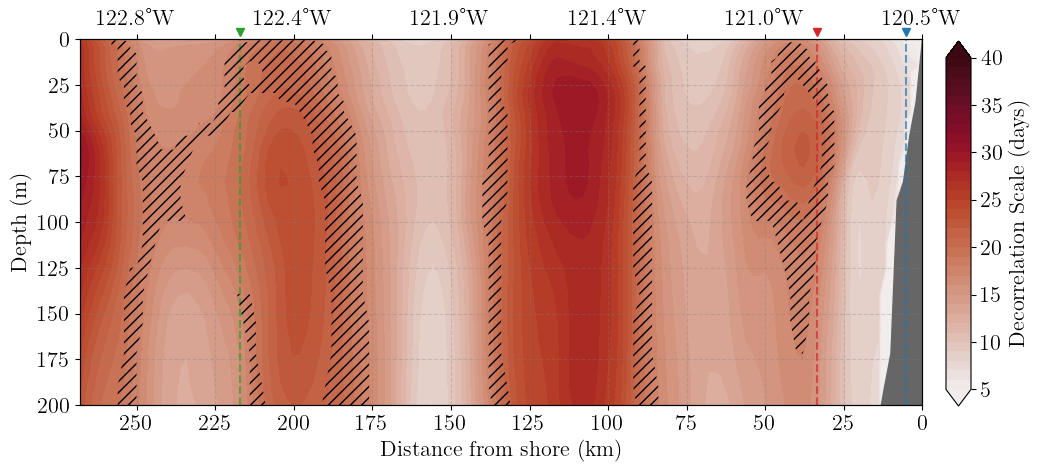

In [23]:
# Set plotting parameter
level = np.arange(5,40+1,1)

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist,abs(depth),Lt_days.T, levels=level, cmap=cmo.amp, extend='both')

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    dist,
    abs(depth),
    data_mask.T,
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
)

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label('Decorrelation Scale (days)')
cbar.set_ticks(np.arange(5,40+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'fig09.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


Save intermediate data 

In [24]:
#--- Autocorrelation and decorrelation scales ---# 

# Check if file exists, then delete it
file_path = PATH + "/mitgcm_transect_temporal_scale_" + option_var  + "CalCOFI_line80_unc.npz"
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Temporal decorrelation length scale from the MIT gcm model out of ' + option_var + ' along CalCOFI line 80. Here, the annual and semi-annual cycles are removed before computing the decorrelation scale.',
    'source': 'MITgcm model data from SWOT_MARA_RUN4_LY',
    'coordinates units': 'km'
}

# Save data arrays and metadata to a .npz file
np.savez(file_path, 
            Lt_days         = Lt_days,           # Units: days
            Lt_stdm_days    = Lt_stdm_days,      # Units: days
            dist            = dist,
            depth           = depth,
            metadata        = metadata
            )